In [1]:
print("hello")

hello


In [1]:
import glob
import math
import random
import os
from icecream import ic

import cv2
import einops
from PIL import Image
import scipy.io as sio
import mediapy as media
import numpy as np
import pandas as pd
import queue
import seaborn as sns
import tensorflow as tf
import tqdm
import jax
import sklearn
import matplotlib.pyplot as plt
import cv2

I0000 00:00:1786948960.820531    6563 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
from models.rvm_jax import * 

In [3]:
model_variant = 'S'
ratio = 1
model = VideoSiamMAE(
    tokenizer=Tokenizer(
        patch_embedding=PatchEmbedding(patch_size=[1, 16, 16], num_features=384),  # confirmed by checkpoint: encoder dim 384
        posenc=SincosPosEmb(base_token_shape=[16, 16]),
    ),
    encoder=Transformer.from_variant_str(variant_str=model_variant, dtype=jax.numpy.bfloat16),  # checkpoint confirms: 384 dim, 6 heads (kernel [384,6,64]), mlp 1536
    rnn_core=GatedTransformerCore(
        transformer=CrossAttentionTransformer(
            num_layers=4,
            num_heads=8,         # paper Table 5; if this errors, read true count off the error (see note)
            num_feats=384,
            mlp_dim=2048,        # ← THE FIX: checkpoint expects (384, 2048), flat value, not 4×dim
            dtype=jax.numpy.bfloat16,
        ),
        initializer=RandomStateInit(),
        token_dim=384,
        state_layer_norm=nn.LayerNorm(epsilon=0.0001, use_scale=True, use_bias=False),
    ),
    latent_emb_dim=384,
    # Decoder: fixed across all sizes — checkpoint confirms 512 dim, 16 heads (kernel [512,16,32]), mlp 2048
    decoder=CrossAttentionTransformer(
        num_layers=8,
        num_heads=16,
        num_feats=512,
        mlp_dim=2048,
        dtype=jax.numpy.bfloat16,
    ),
    decoder_embedder=nn.Dense(512),   # checkpoint confirms: kernel (384, 512)
    delta_embedder=nn.Dense(512),     # checkpoint confirms: kernel (64, 512) — delta is 64-dim Fourier-embedded upstream
    latent_posenc=SincosPosEmb(),
    detokenizer=Detokenizer(patch_size=(16, 16), num_features=3),  # checkpoint confirms: (512, 768) = 16·16·3
    decoder_emb_dim=512,
    masking_ratio=ratio,
    decoder_proj = DecoderProj(encoder_dim = 384, hidden_dim = None)
)



In [4]:
import flax

def merge(init_p, ckpt_p):
  """ckpt values win; init values fill the gaps. Recurses on nested dicts."""
  init_p = flax.core.unfreeze(init_p)
  out = {}
  for k, v in init_p.items():
    if k not in ckpt_p:
      out[k] = v                                  # new: decoder_proj
    elif isinstance(v, dict):
      out[k] = merge(v, ckpt_p[k])
    else:
      c = np.asarray(ckpt_p[k])
      assert c.shape == v.shape, f'{k}: ckpt {c.shape} vs model {v.shape}'
      out[k] = jnp.asarray(c)
  return out


def recover_tree(flat_dict):
  tree = {}
  for k, v in flat_dict.items():
    parts = k.split("/")
    node = tree
    for part in parts[:-1]:
      if part not in node:
        node[part] = {}
      node = node[part]
    node[parts[-1]] = v
  return tree

restored_params = recover_tree(np.load("/home/rvm/rvm_ckpts/pretrain_rvm_small16_256_204031069.npz", allow_pickle=False))
count = sum([np.prod(v.shape) for v in jax.tree_util.tree_leaves(restored_params)])
print(f'number of params {model_variant} = {count}')


dummy_src, dummy_tgt = np.random.randn(1, 4, 256, 256, 3), np.random.randn(1, 4, 256, 256, 3)
dummy_deltas = np.array([4, 5, 6, 7])

key = jax.random.PRNGKey(0)
rng, rng2 = jax.random.split(key)

init_params = model.init(
    {'params': rng, 'default': rng2},
    dummy_src, dummy_tgt, dummy_deltas,
    method=VideoSiamMAE.reconstruct,
)['params']
params = merge(init_params, restored_params)



number of params S = 67480448


2026-08-17 06:42:56.591924: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-08-17 06:43:00.440432: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-08-17 06:43:08.865432: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-08-17 06:43:13.912012: W external/xla/xla/service/gpu/au

In [5]:
def leafkeys(p, prefix=()):
  for k, v in flax.core.unfreeze(p).items():
    if isinstance(v, dict): yield from leafkeys(v, prefix + (k,))
    else: yield prefix + (k,)

ck, mk = set(leafkeys(restored_params)), set(leafkeys(params))
print('in ckpt, unused by model:', ck - mk)   # should be empty
print('fresh (not in ckpt):', mk - ck)        # should be exactly decoder_proj/*

print(jax.tree_util.tree_map(lambda x: x.shape, params['decoder_proj']))
# {'Dense_0': {'kernel': (512, 384), 'bias': (384,)}}

in ckpt, unused by model: set()
fresh (not in ckpt): {('decoder_proj', 'Dense_0', 'bias'), ('decoder_proj', 'Dense_0', 'kernel')}
{'Dense_0': {'bias': (384,), 'kernel': (512, 384)}}


In [6]:
rng_seed = 0
rng_key = {'default': jax.random.PRNGKey(rng_seed)}
@jax.jit
def forward(params, source, target, target_deltas):
    return model.apply(
        {'params': params},
        source, target, target_deltas,
        method=model.reconstruct,
        rngs=rng_key,
    )

In [7]:
cap = cv2.VideoCapture("cycling.mp4")

fps = cap.get(cv2.CAP_PROP_FPS)
num_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = num_frames / fps

print(f"FPS: {fps}")
print(f"Frames: {num_frames}")
print(f"Duration: {duration:.2f} s")

# cap.release()

frames = []
at = 0
while True:
    ret, frame = cap.read()
    if not ret: break
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frame = cv2.resize(frame, (256, 256))
    frame = frame/255.0
    # if at % 3 == 0:
    frames.append(frame)    
    at += 1

ic(len(frames))

FPS: 29.916666666666668
Frames: 307
Duration: 10.26 s


ic| len(frames): 307


307

In [8]:
source_frames = np.array(frames[:4])[None, ...]
target_frames = np.array(frames[4:8])[None, ...]
ic(source_frames.shape, target_frames.shape)
# target_deltas = np.array([6, 7, 8, 9])
target_deltas = np.array([4, 5, 6, 7])

ic| source_frames.shape: (1, 4, 256, 256, 3)
    target_frames.shape: (1, 4, 256, 256, 3)


In [9]:
output = forward(params, source_frames, target_frames, target_deltas)
recon = output['reconstructed']


image = np.asarray(recon[0, 0]).astype(np.float32)

print(image.shape, image.min(), image.max())

# [0, 1] -> [0, 255]
image = np.clip(image, 0.0, 1.0)
image = (image * 255.0).astype(np.uint8)

# RGB -> BGR for OpenCV
image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

cv2.imwrite(f"image_{ratio}.png", image)

2026-08-17 06:43:26.469234: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-08-17 06:43:26.469620: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-08-17 06:43:26.469966: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-08-17 06:43:26.470425: W external/xla/xla/service/gpu/au

(256, 256, 3) 0.10205078 0.65234375


True

In [19]:
print(recon.shape)
print(recon.dtype)
print(recon.min(), recon.max(), recon.mean())

(1, 4, 256, 256, 3)
bfloat16
-0.0189209 0.894531 0.341797


Text(0.5, 1.0, '0.95 masking')

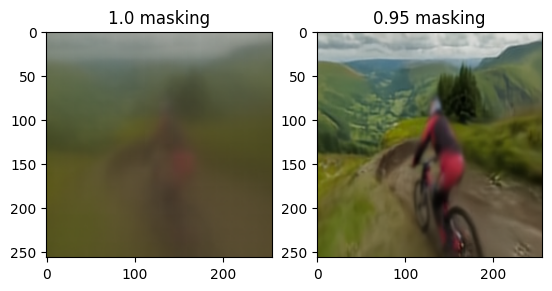

In [11]:
from matplotlib import pyplot as plt

image_0 = cv2.imread("image_1.png")
image_95 = cv2.imread("image_95.png")
image_0 = cv2.cvtColor(image_0, cv2.COLOR_BGR2RGB)
image_95 = cv2.cvtColor(image_95, cv2.COLOR_BGR2RGB)



plt.subplot(1, 2, 1)
plt.imshow(image_0)
plt.title("1.0 masking")


plt.subplot(1, 2, 2)
plt.imshow(image_95)
plt.title("0.95 masking")

In [ ]:
image = numpy.array(image).astype(numpy.float32)

from matplotlib import pyplot as plt
plt.imshow(image)
plt.title(".95 masking")
plt.show()

In [ ]:
image = numpy.array(image).astype(numpy.float32)

from matplotlib import pyplot as plt
plt.imshow(image)
plt.title("1.0 masking")
plt.show()

In [ ]:
output.keys()

In [ ]:
output['representation'].shape, output['masked_indices'].shape

In [ ]:
output['masked_indices'][:, 0, :, :] # 1 if its masked

ema, vit encoder

ic| source.shape: (1, 4, 256, 256, 3) <br>
    target.shape: (1, 4, 256, 256, 3) <br>
    target_deltas: np.array([4, 5, 6, 7]) 

In [ ]:
decoder_emb_dim = 512
encoder_emb_dim = 384

In [ ]:
ema_params = jax.tree.map(lambda x: x.copy(), restored_params)   # init: exact copy

# each step, after the optimizer update
m = 0.996                      
ema_params = jax.tree.map(lambda e, p: m * e + (1 - m) * p, ema_params, restored_params)

tgt = jax.lax.stop_gradient(
    model.apply({'params': ema_params}, target_frames,
                method=VideoSiamMAE.encode_target))

In [ ]:
tgt.shape

In [ ]:
import torch
ckpt_path = '/home/rvm/evals/intphy2/IntPhys2/checkpoint/videomaev2/vit_g_hybrid_pt_1200e.pth'
checkpoint = torch.load(ckpt_path)
checkpoint.keys()